### 🟢1.Title Section

# 🧠 Mental Health in Tech Survey – Data Cleaning & Analysis
## Name: Jinsha uv  
## Internship: Data Science Intern  
## Objective:
This project focuses on cleaning and preprocessing the OSMI Mental Health dataset to make it suitable for analysis and machine learning.
## 📂 Dataset
OSMI Mental Health in Tech Survey Dataset (Kaggle)

## 🛠️ Tools Used
- Python
- Pandas
- NumPy
- Matplotlib / Seaborn

### 🟢2. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

* Importing necessary libraries for data analysis and visualization.

### 🟢3. Load Dataset

In [3]:
df=pd.read_csv("survey.csv")
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


* Loading dataset and displaying first 5 rows.

### 🟢4. Basic Exploration( Initial Data Exploration)


In [4]:
print("Shape:", df.shape)
df.info()
df.describe()
df.isnull().sum()

Shape: (1259, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   ob

Timestamp                       0
Age                             0
Gender                          0
Country                         0
state                         515
self_employed                  18
family_history                  0
treatment                       0
work_interfere                264
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence         0
coworkers                       0
supervisor                      0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
comments                     1095
dtype: int64

Understanding the structure, size, and missing values in the dataset.
* Dataset contains missing values
* Mixed data types
* Needs cleaning

## 🧹5.Data Cleaning

###  5.1 Drop Irrelevant Columns( Removing unnecessary columns)

In [5]:
df.drop(['Timestamp', 'comments', 'state'], axis=1, inplace=True)

In [6]:
df.head() #(to check the irrelevant columns are removed)

,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,37,Female,United States,NaN,No,Yes,Often,6-25,No,Yes,...,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No
1,44,M,United States,NaN,No,No,Rarely,More than 1000,No,No,...,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No
2,32,Male,Canada,NaN,No,No,Rarely,6-25,No,Yes,...,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No
3,31,Male,United Kingdom,NaN,Yes,Yes,Often,26-100,No,Yes,...,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes
4,31,Male,United States,NaN,No,No,Never,100-500,Yes,Yes,...,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No


* Columns like Timestamp, comments, and state are not useful for analysis.

###  5.2. Handle Missing Values

In [11]:
# Fill Age
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill categorical columns
for col in df.select_dtypes(include='object'):
    df[col] = df[col].fillna(df[col].mode()[0])

#flag as "unknown"
df['self_employed'] = df['self_employed'].fillna("Unknown")

- Numerical columns → filled with median  
- Categorical columns → filled with mode
- flag as unknown  

###  5.3 Fix Age Column( Cleaning Age Column)

In [8]:
df = df[(df['Age'] >= 18) & (df['Age'] <= 60)]

* Removing unrealistic values (negative or extremely high ages).

### 5.4 Remove Duplicates

In [13]:
df[df.duplicated()]
df.drop_duplicates(inplace=True)

* Removing Duplicate Records

### 5.5 Standardize Column Names

In [14]:
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

* Standardize column names(lowercase, underscores,spaces)

### 5.6 Clean Gender Column

In [15]:
df['gender'] = df['gender'].str.lower().str.strip() 

def clean_gender(x):
   if 'male' in x or 'm' in x:
       return 'male' 
   elif 'female' in x or 'f' in x:
       return 'female' 
   else: return 'other'

df['gender'] = df['gender'].apply(clean_gender)

* The dataset contains inconsistent gender labels.

### 5.6 Convert Data Types

In [16]:
df['age'] = pd.to_numeric(df['age'], errors='coerce')

* Convert data types (strings to numeric where needed)

## 📉 6. Outlier Detection (Boxplot + IQR)

### Boxplot (Before)

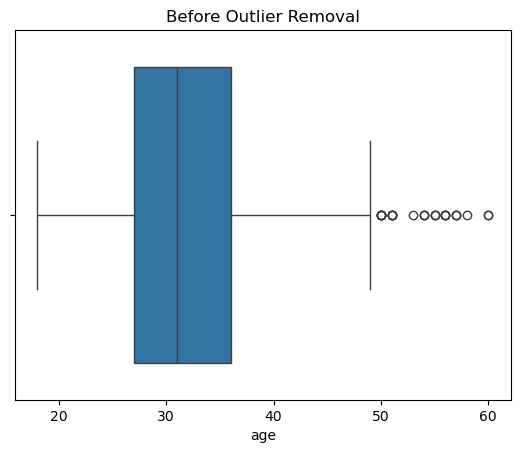

In [17]:

plt.figure()
sns.boxplot(x=df['age']) 
plt.title("Before Outlier Removal")
plt.show()


### IQR Method

In [18]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)

IQR = Q3 - Q1 

lower = Q1 - 1.5 * IQR 
upper = Q3 + 1.5 * IQR 

df = df[(df['age'] >= lower) & (df['age'] <= upper)]

### Boxplot (After)

plt.figure()
sns.boxplot(x=df['age'])
plt.title("After Outlier Removal")
plt.show()

* Extreme values removed and Distribution is now stable 

### 🟢7. Save Cleaned Data

In [22]:
df.to_csv("cleaned_osmi.csv", index=False)

* Save  the cleaned dataset as a new CSV file

### 📊 7. Exploratory Data Analysis (EDA)

### 7.1 Age Distribution

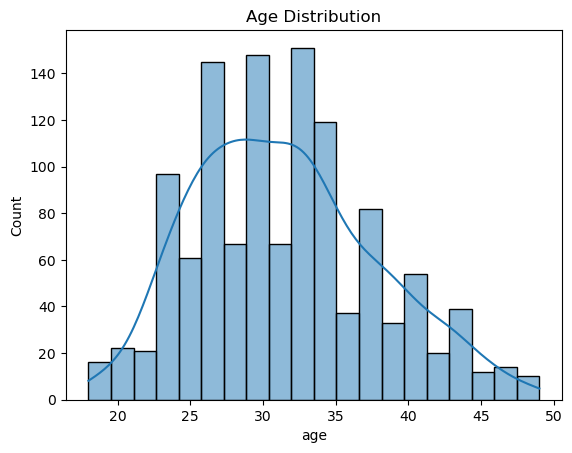

In [23]:
sns.histplot(df['age'], bins=20, kde=True) 
plt.title("Age Distribution") 
plt.show()

* Most participants are aged 20–40

### 7.2 Gender Distribution

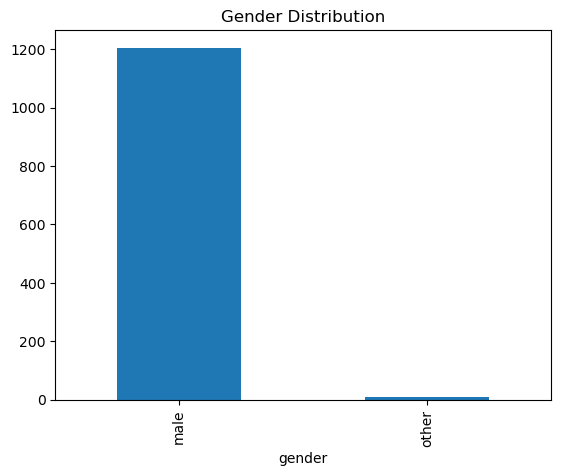

In [24]:
df['gender'].value_counts().plot(kind='bar') 
plt.title("Gender Distribution")
plt.show()

* Majority are male

### 7.3 Treatment Analysis

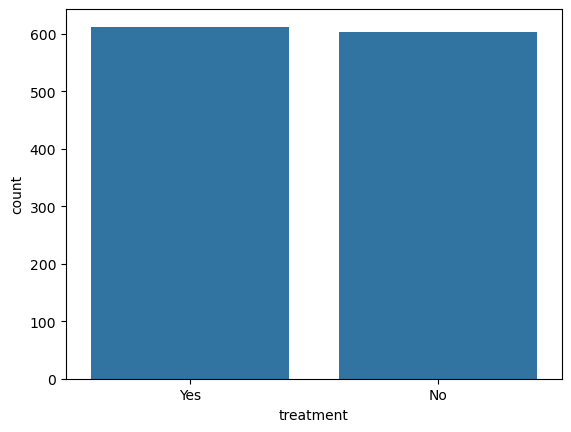

In [25]:
sns.countplot(x='treatment', data=df) 
plt.show()

* Many individuals seek treatment

### 7.4 Family History vs Treatment

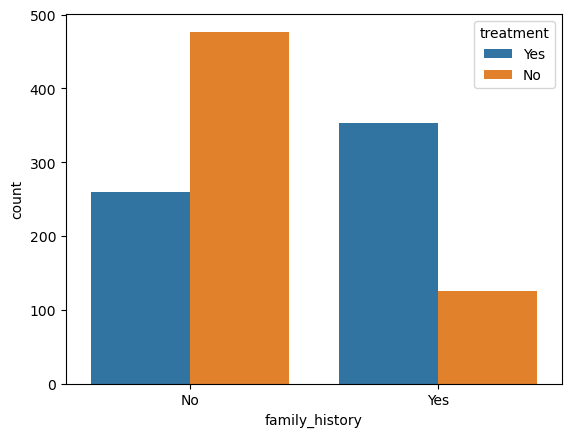

In [26]:
sns.countplot(x='family_history', hue='treatment', data=df)
plt.show()


* Strong correlation with treatment

### 7.5 Work Interference


sns.countplot(x='work_interfere', hue='treatment', data=df) 
plt.xticks(rotation=45) 
plt.show()

* Mental health affects productivity

### 7.6 Remote Work 

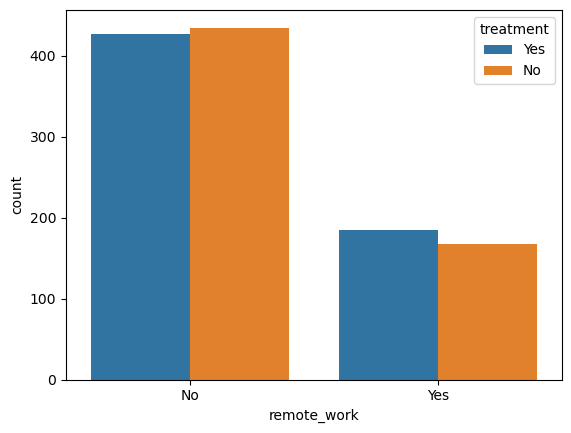

In [28]:
sns.countplot(x='remote_work', hue='treatment', data=df) 
plt.show()

* Mixed effect on mental health

### 7.7 Correlation Heatmap

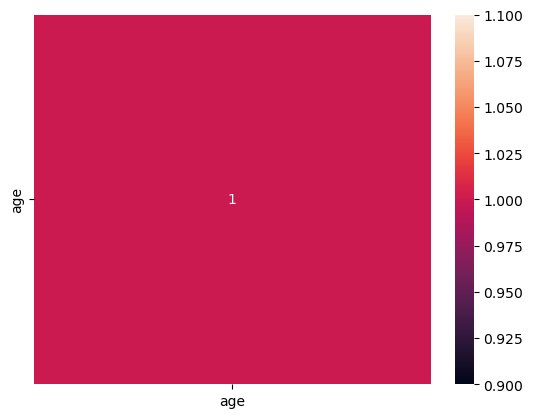

In [29]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()


* Family history strongly linked with treatment

### 📌 8. Final Insights

* Mental health awareness is increasing
* Family history is a major factor
* stress impacts mental health
* Dataset is now clean and reliable


### ✅ 9. Conclusion

The dataset was successfully cleaned and analyzed.
Key preprocessing steps improved data quality, enabling meaningful insights.

This dataset is now ready for:

* Machine Learning models
* Predictive analysis
* Further research